<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/%C3%81rboles_de_decisi%C3%B3n_ipynb_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Árboles de decisión

###Los árboles de decisión son métodos de aprendizaje de máquinas muy utilizados debido a su buen rendimiento y su explicabilidad. Un árbol de decisión no siempre tiene buen rendimiento, por lo que se proponen técnicas de ensamble de árboles de decisión aislados para generar un estimador más robusto que el estimador único por el que está conformado el ensamble.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.tree # Árboles de decisión
import sklearn.ensemble # Ensambles de modelos
import sklearn.model_selection

Para este ejercicio, utilizaremos un conjunto de datos de predicción de diabetes dado una serie de parámetros fisiológicos de un paciente.

In [5]:
diabetes = pd.read_csv("diabetes.csv")

In [6]:
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Para ilustrar la construcción de un árbol de decisión utilizaremos sólo un par de variables del conjunto de datos.

<Axes: xlabel='Glucose', ylabel='BMI'>

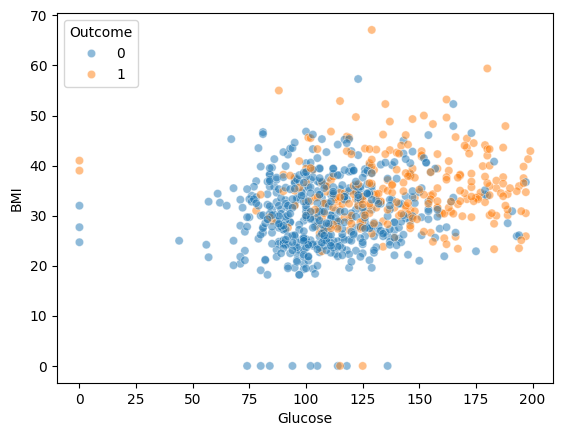

In [7]:
sns.scatterplot(
    data = diabetes,
    x = "Glucose",
    y = "BMI",
    hue = "Outcome",
    alpha = 0.5
)

# Árbol de decisión

Para la construcción de un árbol de decisión, primero debemos definir una métrica a optimizar. En el caso de los árboles de decisión, una métrica que podemos optimizar es la entropía. En donde a medida que vamos tomando decisiones buscamos ganar información o disminuir la entropía.

La definición de entropía que utilizaremos es la siguiente:

$$
H(X)=- \sum_{i}p(x_i) \log_2 p(x_i)
$$

La entropía **$H(X)$** mide el grado de desorden o la incertidumbre de un conjunto de datos. Si estuviéramos jugando a adivinar etiquetas, diríamos que:<br>**La Entropía baja (cercano a 0):** Los datos son predecibles (casi todas las etiquetas son iguales).<br>**La Entropía alta (cercano a 1):** Los datos son diversos y difíciles de predecir.

**La Probabilidad $p(x_i)$:** Es la frecuencia con la que aparece una etiqueta específica. Si una etiqueta es muy común, su probabilidad es cercana a 1.<br>**La "Sorpresa" o Información $(-\log_2 p(x_i))$:** Nos explica que si algo es muy probable, no nos da mucha información.Si algo es muy raro, nos da mucha información cuando ocurre (mucha sorpresa). El signo negativo asegura que el resultado sea positivo, ya que el logaritmo de una fracción es negativo.El Sumatorio $\sum$: Básicamente, estamos calculando el promedio de sorpresa de todas las etiquetas posibles en nuestro conjunto $X$.

In [8]:
def entropy(data):
    classes = np.unique(data)
    entropies = []
    for c in classes:
        p = sum(data == c) / len(data)
        current_entropy = p * np.log2(p)
        entropies.append(current_entropy)
    return -1 * sum(entropies)

Para comenzar, podemos estimar la entropía total del conjunto de datos

In [9]:
entropy(diabetes.Outcome)

np.float64(0.9331343166407831)

Ahora, debemos tomar una decisión, con la cual buscamos disminuir la entropía de cada uno de los subconjuntos obtenidos posterior a la decisión.

In [10]:
entropy(diabetes.Outcome[diabetes.Glucose >= 175])

np.float64(0.6699960320994333)

In [11]:
entropy(diabetes.Outcome[diabetes.Glucose < 175])

np.float64(0.8941290186253704)

**Nota:** Al dividir los datos usando el umbral de Glucose = 175, observamos que la entropía en ambos subgrupos disminuye respecto a la inicial (0.933). Especialmente en el grupo de glucosa alta (0.669), la incertidumbre se reduce notablemente. Esto indica que la glucosa es un buen predictor para separar las clases."

**La Antropía Ponderada:**
<br>Para estimar la entropía general de la decisión que tomamos debemos calcular un promedio ponderado de cada una de las entropías de cada subconjunto de datos.

In [12]:
def weighted_entropy(data, feature, label, threshold):
    indices = data[feature] >= threshold
    entropy_0 = entropy(data[label][indices])
    entropy_1 = entropy(data[label][~indices])
    return entropy_0 * (sum(indices) / len(indices)) + entropy_1 * (sum(~indices) / len(indices))


In [13]:
weighted_entropy(diabetes, "Glucose", "Outcome", 175)

np.float64(0.8774941485316485)

Nota: Con la función **weighted_entropy**, no solo calculamos las nuevas entropías, sino que les damos un "peso" basado en cuántos datos hay en cada grupo.

Si un subgrupo tiene muchísimos datos, su entropía influye más en el promedio.

En caso de que el resultado de la Antropía Ponderada sea menor que el resultado original (0.933), significa que, en promedio, ahora tenemos menos incertidumbre que antes.

# Ganancia de Información (IG)

Para determinar la mejor variable y el mejor umbral para la decisión del nodo del árbol debemos optimizar la ganancia de información de la decisión con la siguiente definición:

$$
IG(Y,X) = E(Y) - E(Y|X)
$$

Donde a la entropía total del conjunto de datos $E(Y)$ le restamos la entropía promedio $E(Y|X)$ de la decisión $Y$. Esto se traduce como:<br>***Ganancia = (Incertidumbre que tenía al principio) - (Incertidumbre que tengo después de dividir).***

In [14]:
entropy(diabetes.Outcome) - weighted_entropy(diabetes, "Glucose", "Outcome", 175)

np.float64(0.055640168109134525)

**Nota:** Al calcular la **Ganancia de Información (IG)**, cuantificamos cuánto valor aporta la variable 'Glucose' con un umbral de 175. Obtenemos una ganancia de 0.0556, lo que confirma que esta división reduce la incertidumbre total del dataset. El árbol de decisión utilizará este valor para comparar esta pregunta con todas las demás posibles y así elegir la mejor ruta de clasificación.

Calculamos las entropías asociadas a un barrido de umbrales en un par de variables.

In [15]:
glucose_information_gain_sweep = []
glucose_thresholds = np.linspace(diabetes.Glucose.min(), diabetes.Glucose.max(), 100)
for threshold in glucose_thresholds:
    glucose_information_gain_sweep.append(entropy(diabetes.Outcome) - weighted_entropy(diabetes, "Glucose", "Outcome", threshold))

<Axes: >

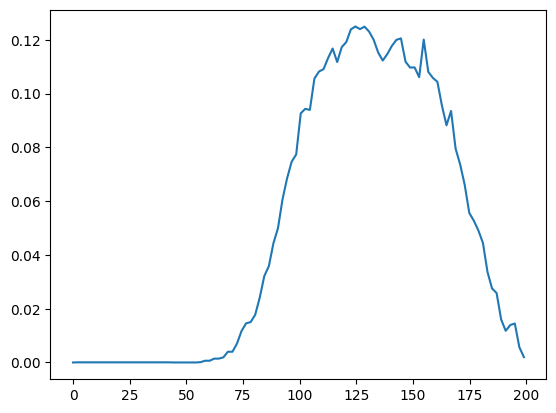

In [16]:
sns.lineplot(
    x = glucose_thresholds,
    y = glucose_information_gain_sweep
)

**Nota:** Este gráfico representa el proceso de optimización del modelo. Al realizar un barrido sobre diferentes umbrales de glucosa, buscamos aquel que maximice la Ganancia de Información. Observamos que el valor óptimo se encuentra cerca de 125. Usar este umbral reducirá la entropía del sistema mucho más que el valor de 175 que probamos inicialmente (cuya ganancia era de apenas 0.055)."

Aunque buscamos maximizar la ganancia de información, en problemas reales es difícil alcanzar el valor máximo (la entropía inicial). Una ganancia de 0.12 mediante la variable Glucose es un excelente punto de partida, indicando que es un predictor potente, pero que necesitaremos combinarlo con otras variables para alcanzar una certeza total.

In [17]:
bmi_information_gain_sweep = []
bmi_thresholds = np.linspace(diabetes.BMI.min(), diabetes.BMI.max(), 100)
for threshold in bmi_thresholds:

    bmi_information_gain_sweep.append(entropy(diabetes.Outcome) - weighted_entropy(diabetes, "BMI", "Outcome", threshold))

<Axes: >

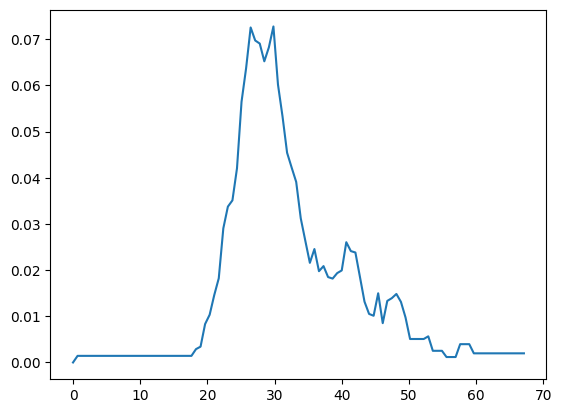

In [18]:
sns.lineplot(
    x = bmi_thresholds,
    y = bmi_information_gain_sweep
)

**Nota:** Al realizar el barrido para el **BMI**, identificamos un pico de Ganancia de Información de ~0.07 en el umbral de 30. Aunque el BMI es un indicador relevante, su ganancia es menor que la de la Glucosa (0.12). Por lo tanto, en una jerarquía lógica, la Glucosa es una variable más prioritaria para clasificar correctamente a los pacientes.

Text(0.5, 0, 'threshold')

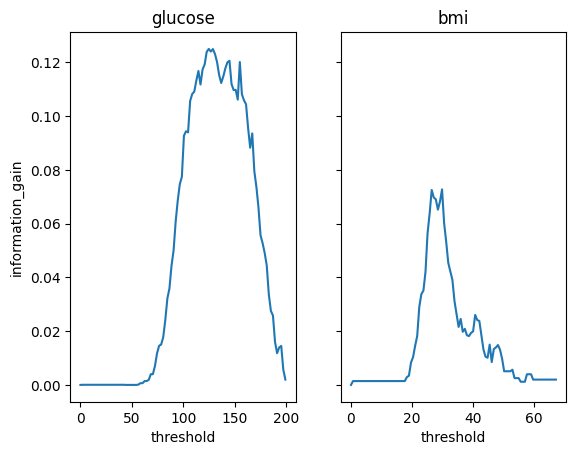

In [19]:
fig, axs = plt.subplots(nrows=1,ncols=2, sharey=True)
sns.lineplot(
    x = glucose_thresholds,
    y = glucose_information_gain_sweep,
    ax = axs[0]
)
sns.lineplot(
    x = bmi_thresholds,
    y = bmi_information_gain_sweep,
    ax = axs[1]
)
axs[0].set_title("glucose")
axs[1].set_title("bmi")
axs[0].set_ylabel("information_gain")
axs[0].set_xlabel("threshold")
axs[1].set_xlabel("threshold")

Seleccionamos el umbral que nos aporta la mayor ganancia de información.

In [20]:
optimal_glucose_threshold = glucose_thresholds[np.argmax(glucose_information_gain_sweep)]
optimal_glucose_threshold

np.float64(124.62626262626262)

In [21]:
entropy(diabetes.Outcome[diabetes.Glucose >= optimal_glucose_threshold])

np.float64(0.9773203829731114)

In [22]:
entropy(diabetes.Outcome[diabetes.Glucose < optimal_glucose_threshold])

np.float64(0.6930190480473644)

**Nota:** Finalmente, automatizamos la selección del mejor umbral utilizando np.argmax, encontrando que **124.62 mg/dL** es el punto donde maximizamos la ganancia de información.

Al observar las entropías resultantes, vemos que el grupo con glucosa baja presenta una incertidumbre mucho menor (0.693), lo que facilita la predicción en esa rama del árbol. Este proceso de 'dividir y conquistar' es la base sobre la cual el Árbol de Decisión continuará expandiéndose."

El umbral óptimo identificado de **124.62 mg/dL** es sumamente coherente desde una perspectiva clínica, ya que se sitúa en el límite crítico de diagnóstico de diabetes (126 mg/dL).

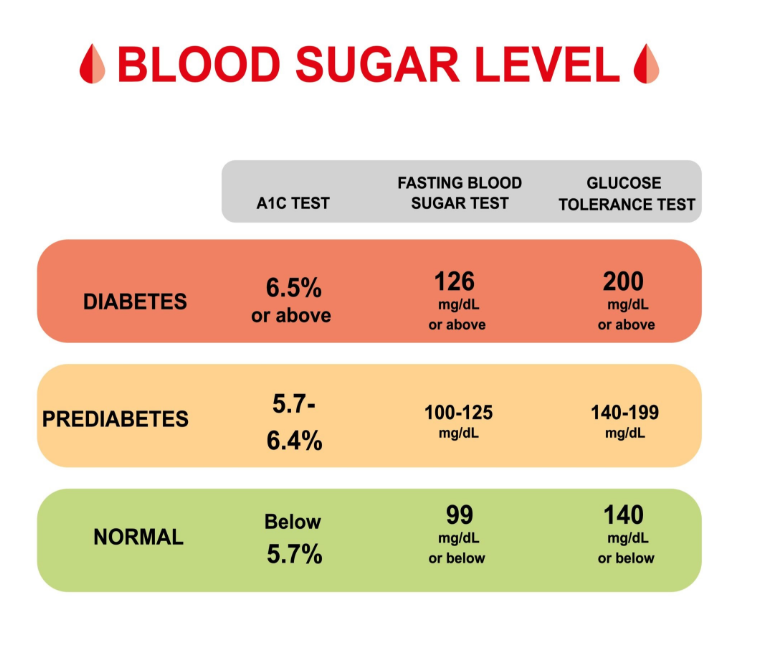

Utilizamos la implementación del árbol de decisión de sklearn para calcular la misma decisión.

In [23]:
single_decision = sklearn.tree.DecisionTreeClassifier(max_depth=1, criterion = "entropy")
single_decision = single_decision.fit(diabetes[["Glucose", "BMI"]], diabetes.Outcome)

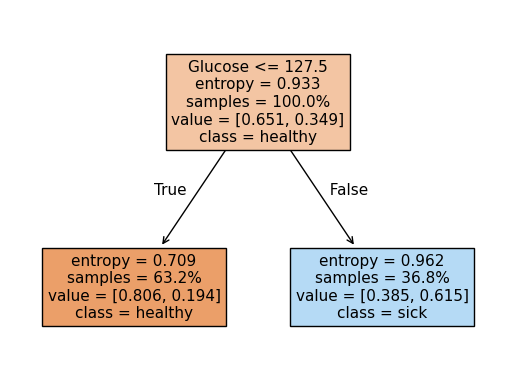

In [24]:
sklearn.tree.plot_tree( # Función que nos permite visualizar el árbol de decisión ajustado.
    single_decision, # Objeto de nuestro árbol de decisión entrenado.
    feature_names = ["Glucose", "BMI"], # Nombres de las variables utilizadas para entrenar.
    class_names = ["healthy","sick"], # Nombre de las clases que estamos prediciendo.
    label = "all", # Etiquetamos todas características de cada nodo.
    proportion = True, # Visualizamos las proporciones de datos en cada nodo de decisión,
    filled=True, # Coloreamos los nodos
    fontsize=11, # Establecemos el tamaño de la letra del texto dentro de cada nodo.
)
plt.show()

**Nota:** Para validar nuestro análisis, implementamos el modelo DecisionTreeClassifier de Scikit-Learn. Es gratificante observar que el algoritmo automático replica nuestra lógica manual: selecciona la Glucosa como la variable principal y establece un umbral de **127.5 mg/dL**, muy cercano a nuestro cálculo de **124.62**.

El árbol logra separar el dataset en un grupo mayoritariamente sano (naranja, 80.6% de pureza) y un grupo con alta prevalencia de enfermedad (azul). Este es el primer paso de un modelo predictivo: convertir la incertidumbre inicial (0.933) en decisiones basadas en datos.

Preparamos el conjunto de datos para poder ajustar un árbol de decisión de mayor profundidad.

In [25]:
diabetes_features = diabetes.iloc[:,:-1]
diabetes_label = diabetes.Outcome

In [26]:
(
    diabetes_features_train,
    diabetes_features_test,
    diabetes_label_train,
    diabetes_label_test
) = sklearn.model_selection.train_test_split(
    diabetes_features,
    diabetes_label,
    test_size=0.33,
    random_state=11
)

In [27]:
tree = sklearn.tree.DecisionTreeClassifier( # Instanciamos nuestro árbol de decisión.
    max_depth=3, # Forzamos que nuestro árbol sólo tenga 3 niveles de profundidad.
    criterion = "entropy"
    )
tree.fit( # Ajustamos nuestro árbol de decisión.
    diabetes_features_train,
    diabetes_label_train
)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

**Nota:** Finalmente, escalamos nuestro análisis entrenando un modelo completo con todas las características disponibles. Al utilizar train_test_split, aseguramos que podremos validar la precisión del modelo con datos desconocidos.

Limitamos la profundidad a 3 niveles para mantener un modelo interpretable y evitar el sobreajuste. En este punto, el algoritmo repetirá de forma recursiva el proceso de maximización de Ganancia de Información que calculamos manualmente, construyendo una jerarquía de decisiones que nos permitirá predecir la presencia de diabetes con mayor confianza.

Calculamos el rendimiento de nuestro árbol de decisión.

In [28]:
print(sklearn.metrics.classification_report(
    diabetes_label_test,
    tree.predict(diabetes_features_test)
))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80       165
           1       0.65      0.45      0.53        89

    accuracy                           0.72       254
   macro avg       0.69      0.66      0.67       254
weighted avg       0.71      0.72      0.71       254



**Nota:** Aunque el modelo alcanza un Accuracy global del 0.72, el análisis por clase revela una debilidad crítica: un Recall de 0.45 para la clase positiva (enfermos).

Esto indica que el modelo es conservador y falla en detectar a más de la mitad de los pacientes diabéticos. En un contexto clínico, esto es peligroso. Para mejorar estos resultados, se podría considerar balancear las clases (oversampling), ajustar los pesos de importancia en el modelo o permitir una mayor profundidad en el árbol para capturar reglas más específicas del grupo enfermo.

Visualizamos el árbol de decisión.

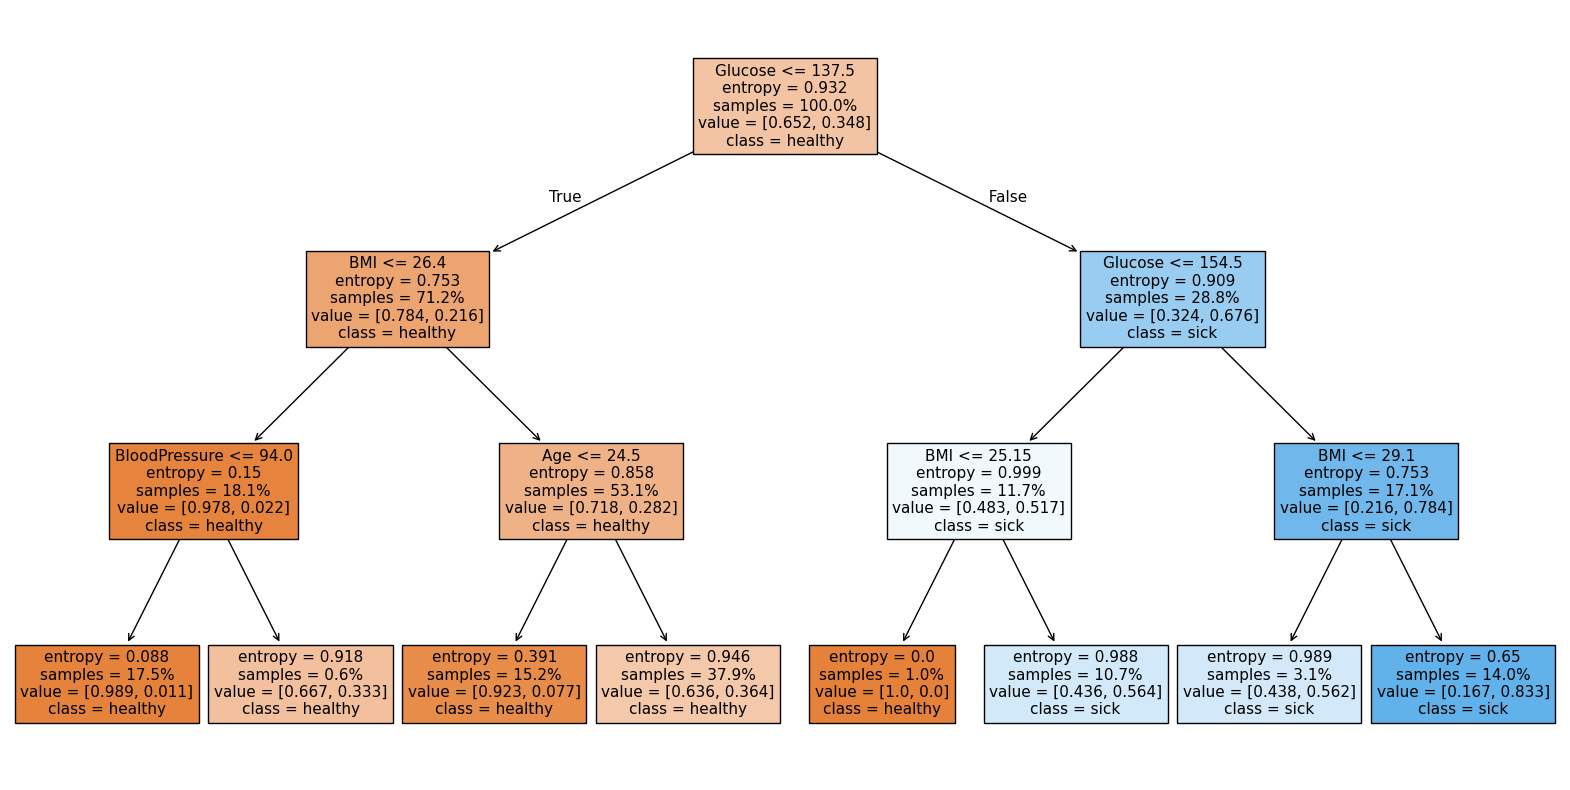

In [29]:
plt.figure(figsize = (20,10))
sklearn.tree.plot_tree( # Función que nos permite visualizar el árbol de decisión ajustado.
    tree, # Objeto de nuestro árbol de decisión entrenado.
    feature_names = diabetes_features.columns, # Nombres de las variables utilizadas para entrenar.
    class_names = ["healthy","sick"], # Nombre de las clases que estamos prediciendo.
    label = "all", # Etiquetamos todas características de cada nodo.
    proportion = True, # Visualizamos las proporciones de datos en cada nodo de decisión,
    filled=True, # Coloreamos los nodos
    fontsize=11, # Establecemos el tamaño de la letra del texto dentro de cada nodo.
)
plt.show()

Un hiperparámetro que podemos ajustar en un árbol de decisión es la profundidad máxima. Visualizamos que tenemos un mejoramiento inicial del rendimiento al aumentar la profundidad, para después descender debido al sobreajuste.

In [30]:
depths = range(1,10)
performances = []
for depth in depths:
    current_tree = sklearn.tree.DecisionTreeClassifier( # Instanciamos nuestro árbol de decisión.
        max_depth=depth, # Forzamos que nuestro árbol sólo tenga 3 niveles de profundidad.
        criterion = "entropy"
    )
    roc_auc = sklearn.model_selection.cross_val_score(
          current_tree,
          diabetes_features,
          diabetes_label,
          scoring="roc_auc"
      ).mean()
    performances.append(roc_auc)

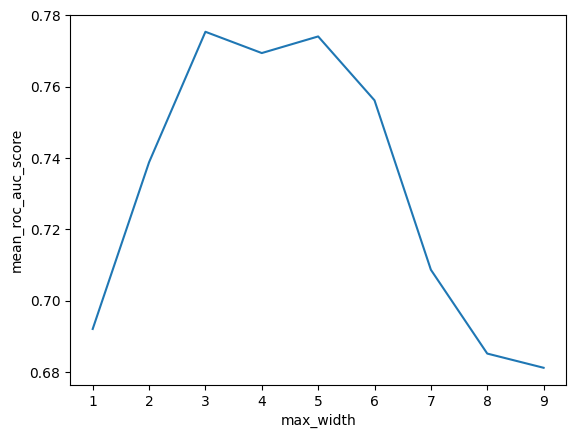

In [31]:
plt.plot(
    depths,
    performances
)
plt.xlabel("max_width")
plt.ylabel("mean_roc_auc_score")
plt.show()

# Conclusiones finales
A través del barrido de hiperparámetros, observamos que el rendimiento del modelo (medido con ROC AUC) alcanza su punto máximo entre una profundidad de 4 y 5.

Superar este nivel no aporta beneficios significativos y corre el riesgo de caer en sobreajuste, donde el árbol memorizaría particularidades del set de entrenamiento en lugar de aprender patrones generales de la diabetes. Por lo tanto, seleccionamos una profundidad de 4 o 5 como la configuración óptima para nuestro clasificador final, equilibrando la capacidad predictiva con la simplicidad del modelo.